# Perceptron Algorithm

The **Perceptron** is one of the simplest types of artificial neural networks used for **binary classification**. It aims to find a **linear decision boundary** that separates two classes of data.  

## Key Components:
- **Feature vector** `x = [x1, x2, ..., xl]` representing an input sample.
- **Weight vector** `w = [w1, w2, ..., wl]` representing the importance of each feature.
- **Bias (threshold)** `w0` to shift the decision boundary.
- **Activation function**: Typically a step function:
  $$
  f(z) = 
  \begin{cases} 
  1 & \text{if } z \ge 0 \\
  -1 & \text{if } z < 0 
  \end{cases}
  $$

## Decision Rule:
$$

\text{If } w^T x + w_0 \ge 0, \text{ assign class } 1, \text{ else class } 2

$$
## Learning Algorithm:
1. Initialize weights `w` and bias `w0` randomly or to zero.
2. For each misclassified sample, update weights using:
$$
w \leftarrow w + \eta \cdot y \cdot x
$$
where `y` is the label (`+1` or `-1`) and `η` is the learning rate.
3. Repeat until all samples are correctly classified or a maximum number of iterations is reached.

## Properties:
- Guarantees convergence **if the classes are linearly separable**.
- Extends to multiple classes using strategies like **one-vs-all** or **Kesler’s construction**.
- Forms the basis for more complex neural networks.



what we'll do:

- Define the Perceptron class.
- Initialize the weights and set the learning rate. 
- Implement the update rule for the weights.
- Train the model and update the weights iteratively.
- Check for convergence and classify new data points.

In [62]:
import numpy as np
import matplotlib.pyplot as plt


### Define the Perceptron Algorithm

In [63]:
class Perceptron:
    def __init__(self, learning_rate=0.1, max_iter=1000):
        self.learning_rate = learning_rate
        self.max_iter = max_iter
        self.w = None
        self.bais = 0
    
    def fit(self, X, y):
        """
        X: Feature (training set)
        y: Labels
        """

        self.w = np.zeros(X.shape[1])

        for _ in range(self.max_iter):
            updated = False

            for i in range(len(X)):
                if y[i] * (np.dot(X[i], self.w)) <= 0:
                    self.w += self.learning_rate * y[i] * X[i]
                    self.bais += self.learning_rate * y[i]
                    updated = True
            
            if not updated:
                break

    def predict(self, X):
        '''
        predict the class for a given feature x.
        '''

        return np.sign(np.dot(X, self.w) + self.bais)

### Training and Testing the Perceptron

In [64]:
X = np.array([[2, 3], [4, 5], [1, 7], [7, 8], [6, 9], [8, 2], [5, 6], [8, 6]])
y = np.array([1, 1, 1, -1, -1, -1, 1, -1])

perceptron = Perceptron(learning_rate=0.1)
perceptron.fit(X, y)

test_data = np.array([[5, 5], [3, 4]])
predictions = perceptron.predict(test_data)

print("Predictions:", predictions)


Predictions: [1. 1.]


### Visualizing the Training Process

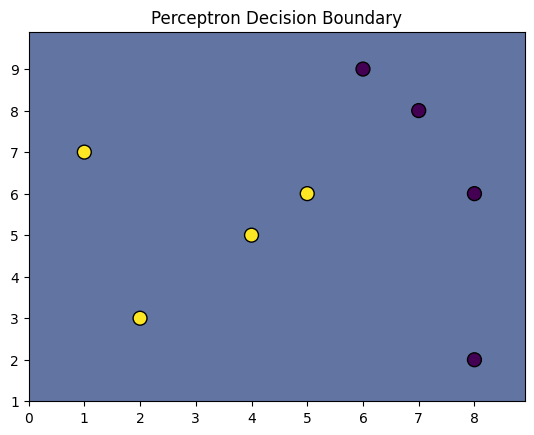

In [65]:
def plot_decision_boundary(X, y, model):
    """
    Plot the decision boundary of the Perceptron.
    """
    # Create a meshgrid for plotting
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                         np.arange(y_min, y_max, 0.1))
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.contourf(xx, yy, Z, alpha=0.8)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', marker='o', s=100)
    plt.title('Perceptron Decision Boundary')
    plt.show()

# Visualize the decision boundary
plot_decision_boundary(X, y, perceptron)


## Using Ggradient Decsent Update Approach

# Gradient Descent

**Gradient Descent** is an optimization algorithm used to **minimize a cost function** by iteratively adjusting parameters in the direction of the **steepest descent** (negative gradient).

## Key Idea:
Given a differentiable cost function \(J(w)\) with respect to weights `w`, we update the weights as:

$$
w \leftarrow w - \eta \cdot \nabla_w J(w)
$$

where:
- \(\eta\) is the **learning rate**, controlling the step size.
- \(\nabla_w J(w)\) is the **gradient** of the cost function with respect to `w`.

## Steps:
1. Initialize weights `w` randomly or to zero.
2. Compute the gradient of the cost function with respect to `w`.
3. Update the weights using the gradient.
4. Repeat until convergence (gradient is near zero) or a maximum number of iterations is reached.

## Properties:
- Works for **any differentiable cost function**.
- Convergence depends on the **learning rate** and the shape of the cost function.
- Can be extended to **stochastic gradient descent (SGD)** by using mini-batches of data.

## Example Use in Linear Classifiers:
For a linear model with cost function based on misclassified points:

$$
J(w) = \sum_{x \in Y} -y (w^T x)
$$

Gradient descent updates the weight vector as:

$$
w \leftarrow w + \eta \sum_{x \in Y} y \cdot x
$$

This is essentially the **batch perceptron update**.


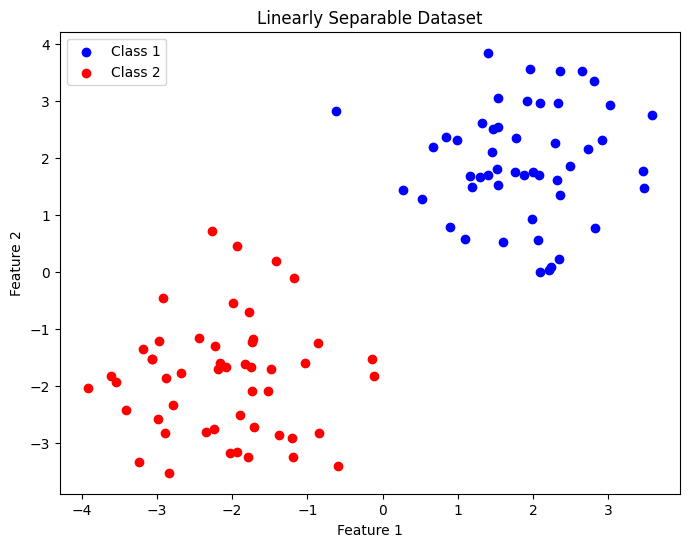

In [66]:
np.random.seed(42)
class_1 = np.random.randn(50, 2) + [2, 2]  # Class 1 centered at (2, 2)
class_2 = np.random.randn(50, 2) + [-2, -2]  # Class 2 centered at (-2, -2)

X = np.vstack((class_1, class_2))
y = np.hstack((np.ones(50), -np.ones(50)))  

plt.figure(figsize=(8,6))
plt.scatter(class_1[:, 0], class_1[:, 1], color='blue', label='Class 1')
plt.scatter(class_2[:, 0], class_2[:, 1], color='red', label='Class 2')
plt.title("Linearly Separable Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

In [67]:
print(X[0])
print(y[0])

[2.49671415 1.8617357 ]
1.0


In [68]:
X_bias = np.c_[np.ones(X.shape[0]), X]
w = np.zeros(X_bias.shape[1])
learning_rate = 0.1


In [69]:
def hinge_loss(w, X, y):
    """
    Hinge loss function for classification.
    """
    margin = y * np.dot(X, w)
    loss = np.maximum(0, 1 - margin)
    return np.mean(loss)

def compute_gradient(w, X, y):
    """
    Compute the gradient of the hinge loss function.
    """
    margin = y * np.dot(X, w)
    gradient = -np.dot((y * (margin < 1)).T, X) / X.shape[0]
    return gradient

def perceptron_gradient_descent(X, y, w, learning_rate, epochs):
    for epoch in range(epochs):
        grad = compute_gradient(w, X, y)
        
        w -= learning_rate * grad
        
        if (epoch+1) % 10 == 0:
            cost = hinge_loss(w, X, y)
            print(f"Epoch {epoch+1}/{epochs}, Cost: {cost}, Weights: {w}")
    
    return w


In [70]:
epochs = 100
final_weights = perceptron_gradient_descent(X_bias, y, w, learning_rate, epochs)

x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

Z = np.dot(np.c_[np.ones(xx.ravel().shape[0]), xx.ravel(), yy.ravel()], final_weights)
Z = Z.reshape(xx.shape)

Epoch 10/100, Cost: 0.025866515051152436, Weights: [0.004      0.49528216 0.43246811]
Epoch 20/100, Cost: 0.010056816465297698, Weights: [-0.013       0.59215529  0.51097663]
Epoch 30/100, Cost: 0.004080372139327662, Weights: [-0.02        0.65346301  0.55318832]
Epoch 40/100, Cost: 0.002220539029944514, Weights: [-0.038       0.68319846  0.5789023 ]
Epoch 50/100, Cost: 0.001116673634359997, Weights: [-0.048       0.71186011  0.59240693]
Epoch 60/100, Cost: 0.00011048391450139028, Weights: [-0.063       0.73914635  0.59872301]
Epoch 70/100, Cost: 0.0, Weights: [-0.065       0.74342566  0.59988302]
Epoch 80/100, Cost: 0.0, Weights: [-0.065       0.74342566  0.59988302]
Epoch 90/100, Cost: 0.0, Weights: [-0.065       0.74342566  0.59988302]
Epoch 100/100, Cost: 0.0, Weights: [-0.065       0.74342566  0.59988302]


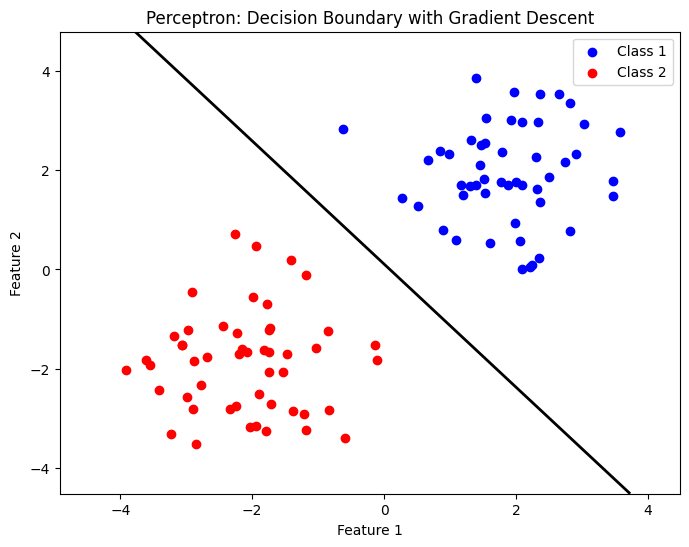

In [71]:
plt.figure(figsize=(8,6))
plt.scatter(class_1[:, 0], class_1[:, 1], color='blue', label='Class 1')
plt.scatter(class_2[:, 0], class_2[:, 1], color='red', label='Class 2')

plt.contour(xx, yy, Z, levels=[0], linewidths=2, colors='black')

plt.title("Perceptron: Decision Boundary with Gradient Descent")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()